In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import warnings
warnings.filterwarnings('ignore')

import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

print("All libraries loaded successfully!")

All libraries loaded successfully!


[nltk_data] Downloading package punkt to C:\Users\PEDDOLLA
[nltk_data]     HARIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\PEDDOLLA
[nltk_data]     HARIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\PEDDOLLA
[nltk_data]     HARIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df=pd.read_csv(r"C:\Users\PEDDOLLA HARIKA\OneDrive\Desktop\Medical_Specialty_Prediction\mtsamples.csv")

In [4]:
df.shape

(4999, 6)

In [5]:
df.info

<bound method DataFrame.info of       Unnamed: 0                                        description  \
0              0   A 23-year-old white female presents with comp...   
1              1           Consult for laparoscopic gastric bypass.   
2              2           Consult for laparoscopic gastric bypass.   
3              3                             2-D M-Mode. Doppler.     
4              4                                 2-D Echocardiogram   
...          ...                                                ...   
4994        4994   Patient having severe sinusitis about two to ...   
4995        4995   This is a 14-month-old baby boy Caucasian who...   
4996        4996   A female for a complete physical and follow u...   
4997        4997   Mother states he has been wheezing and coughing.   
4998        4998   Acute allergic reaction, etiology uncertain, ...   

                medical_specialty                                sample_name  \
0            Allergy / Immunology  

In [6]:
df.columns

Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='str')

In [7]:
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [8]:
df=df.drop(columns="Unnamed: 0")

In [9]:
df.isnull().sum()

description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

In [10]:
df = df.drop(columns=["keywords"])

In [11]:
df = df.dropna(subset=["transcription"])

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
print("\nNumber of unique specialties:", df['medical_specialty'].nunique())


Number of unique specialties: 40


In [14]:
print("\nTop 10 specialties:")
print(df['medical_specialty'].value_counts().head(10))


Top 10 specialties:
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64


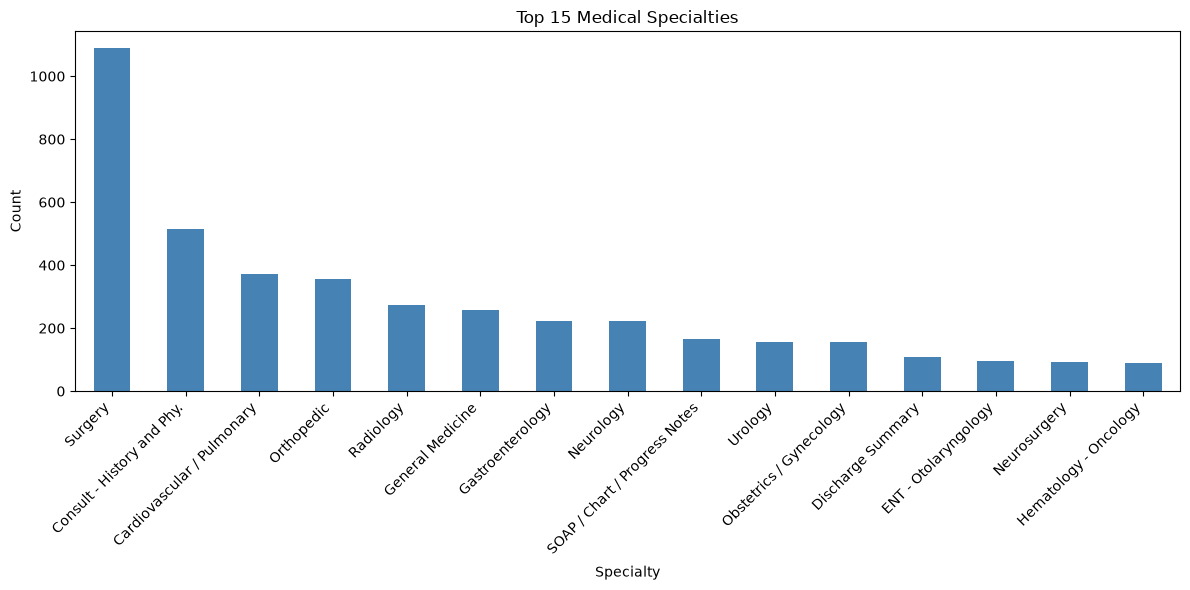

In [15]:
# Plot top 15 specialties
plt.figure(figsize=(12, 6))
df['medical_specialty'].value_counts().head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Keep only top 10 specialties (others have too few samples)
top10 = df['medical_specialty'].value_counts().head(10).index
df_clean = df[df['medical_specialty'].isin(top10)].copy()

In [17]:
# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)           # remove numbers
    text = re.sub(r'[^\w\s]', '', text)       # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df_clean['clean_text'] = df_clean['transcription'].apply(clean_text)

print("Dataset size after cleaning:", df_clean.shape)
print("\nClass distribution:")
print(df_clean['medical_specialty'].value_counts())

Dataset size after cleaning: (3631, 5)

Class distribution:
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64


In [18]:
X = df_clean['clean_text']
y = df_clean['medical_specialty']

# TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTF-IDF matrix shape:", X_tfidf.shape)

Training set size: (2904, 10000)
Test set size: (727, 10000)

TF-IDF matrix shape: (3631, 10000)


In [19]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

In [20]:
# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

In [21]:
# knn 
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

In [23]:
# Compare
print("=" * 40)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print("=" * 40)
print(f" KNeighborsClassifier Accuracy: {knn_acc:.4f}")
print("=" * 40)
print(f"Naive Bayes Accuracy:         {nb_acc:.4f}")
print("=" * 40)

Logistic Regression Accuracy: 0.3494
 KNeighborsClassifier Accuracy: 0.3411
Naive Bayes Accuracy:         0.4801


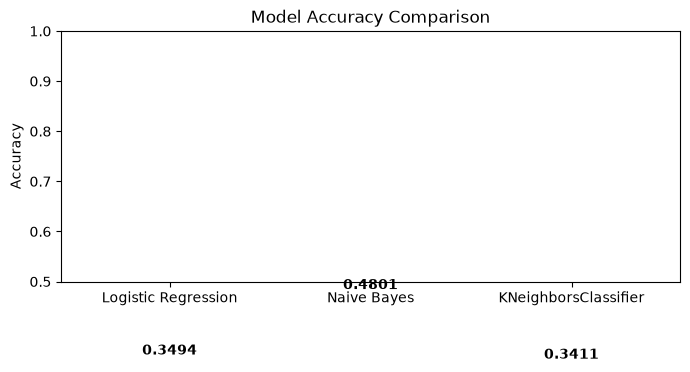

In [ ]:
# Bar chart comparison
plt.figure(figsize=(7, 4))
models = ['Logistic Regression', 'Naive Bayes', 'KNeighborsClassifier']
scores = [lr_acc, nb_acc,knn_acc]
bars = plt.bar(models, scores, color=['steelblue', 'coral'])
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
print("LOGISTIC REGRESSION - Classification Report")
print("=" * 60)
print(classification_report(y_test, lr_pred))

print("KNN - Classification Report")
print("=" * 60)
print(classification_report(y_test, knn_pred))

print("\nNAIVE BAYES - Classification Report")
print("=" * 60)
print(classification_report(y_test, nb_pred))

LOGISTIC REGRESSION - Classification Report
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.26      0.20      0.23        74
    Consult - History and Phy.       0.34      0.55      0.42       103
              Gastroenterology       0.05      0.02      0.03        45
              General Medicine       0.14      0.10      0.11        52
                     Neurology       0.20      0.16      0.17        45
                    Orthopedic       0.10      0.07      0.08        71
                     Radiology       0.27      0.24      0.25        55
 SOAP / Chart / Progress Notes       0.20      0.09      0.12        33
                       Surgery       0.51      0.68      0.58       218
                       Urology       0.00      0.00      0.00        31

                      accuracy                           0.35       727
                     macro avg       0.21      0.21      0.20       727
                  

In [ ]:
print("=" * 55)
print("   CLINICAL TEXT CLASSIFICATION - FINAL SUMMARY")
print("=" * 55)
print(f"\n Dataset: Medical Transcriptions (mtsamples)")
print(f" Total samples used:       {df_clean.shape[0]}")
print(f" Number of categories:     10")
print(f" Train / Test split:       80% / 20%")
print(f" TF-IDF features:          10,000")
print(f"\n{'Model':<25} {'Accuracy':>10}")
print("-" * 37)
print(f"{'Logistic Regression':<25} {lr_acc:>10.4f}")
print(f"{'Naive Bayes':<25} {nb_acc:>10.4f}")
print("-" * 37)
print(f"\n Best model: Naive Bayes ({nb_acc:.2%} accuracy)")
print(f"\n Key finding: Class imbalance (Surgery=1088)")
print(f" affects minority class predictions.")
print(f"\n Future work: Apply SMOTE or use weighted")
print(f" loss to handle class imbalance.")
print("=" * 55)

   CLINICAL TEXT CLASSIFICATION - FINAL SUMMARY

 Dataset: Medical Transcriptions (mtsamples)
 Total samples used:       3631
 Number of categories:     10
 Train / Test split:       80% / 20%
 TF-IDF features:          10,000

Model                       Accuracy
-------------------------------------
Logistic Regression           0.3494
Naive Bayes                   0.4801
-------------------------------------

 Best model: Naive Bayes (48.01% accuracy)

 Key finding: Class imbalance (Surgery=1088)
 affects minority class predictions.

 Future work: Apply SMOTE or use weighted
 loss to handle class imbalance.


In [30]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](10,)","[297.,413.,179.,...,133.,870.,125.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](10,)","[-2.28,-1.95,-2.79,...,-3.08,-1.21,-3.15]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U30](10,)","[' Cardiovascular / Pulmonary',' Consult - History and Phy.', ' Gastroenterology',...,' SOAP / Chart / Progress Notes',' Surgery', ' Urology']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](10, 10000)","[[0.21,0.04,0.39,...,0.08,0.31,0.08], [0.14,0. ,0.18,...,0.45,0.2 ,0.89], [0.09,0.05,0.26,...,0. ,0. ,0.08], ..., [0. ,0. ,0. ,...,0. ,0.19,0.45], [0.76,0.4 ,1.13,...,0.35,0.05,0. ], [0. ,0.03,0.12,...,0.13,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](10, 10000)","[[-9.29,-9.44,-9.15,...,-9.41,-9.22,-9.41], [-9.49,-9.63,-9.46,...,-9.26,-9.45,-8.99], [-9.29,-9.33,-9.15,...,-9.38,-9.38,-9.3 ], ..., [-9.34,-9.34,-9.34,...,-9.34,-9.16,-8.96], [-9.31,-9.54,-9.12,...,-9.58,-9.82,-9.87], [-9.33,-9.3 ,-9.22,...,-9.21,-9.33,-9.33]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [31]:
import joblib

joblib.dump(nb, "medical_specialty_model_nb.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']